In [1]:
# === CELL 1: Imports y dependencias ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
except ImportError:
    print("Instala stable-baselines3 antes de ejecutar este notebook.")

# Breakpoint detection basado en RL quasi-supervisado

- **setup**: tomas dos vectores de entrada: el ndvi y un vector categorico que le indica el landcover (0: bosque, 1: no-bosque)
- **idea**: la ieda es que el sistema tenga dos estados, y aprende a seguir la serie de tiempo en cada uno de ellos.
- **como se usa**: si entrena, se puede cambiar el input de 0 a 1 a ver a que modelo ajusta mejor

### Levanto series verdaderas de NDVI

In [2]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [3]:
df.columns.values

array(['Unnamed: 0', 'lon', 'lat', 'sitio', 'anio', 'mes', 'nubes',
       '2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
       '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
       '2000-06-25', '2000-07-11', '2000-07-27', '2000-08-12',
       '2000-08-28', '2000-09-13', '2000-09-29', '2000-10-15',
       '2000-10-31', '2000-11-16', '2000-12-02', '2000-12-18',
       '2001-01-01', '2001-01-17', '2001-02-02', '2001-02-18',
       '2001-03-06', '2001-03-22', '2001-04-07', '2001-04-23',
       '2001-05-09', '2001-05-25', '2001-06-10', '2001-06-26',
       '2001-07-12', '2001-07-28', '2001-08-13', '2001-08-29',
       '2001-09-14', '2001-09-30', '2001-10-16', '2001-11-01',
       '2001-11-17', '2001-12-03', '2001-12-19', '2002-01-01',
       '2002-01-17', '2002-02-02', '2002-02-18', '2002-03-06',
       '2002-03-22', '2002-04-07', '2002-04-23', '2002-05-09',
       '2002-05-25', '2002-06-10', '2002-06-26', '2002-07-12',
       '2002-07-28', '2002-08-13', '2002-08-29', '

In [4]:
df.shape

(4610, 437)

Ploteo eventos de deforestacion

In [5]:
ndviDataStart = 7
# testPixel = np.arange(0,20)
testPixel = np.random.choice(df.shape[0], size=20, replace=False)

In [6]:
testPixel

array([3921, 3533, 1562, 3957,  706, 2050,  190,  913, 3172,  776, 2836,
       3212, 1829, 3870, 3107,  538, 2844, 1919, 3077, 3331])

### reconstruyo vector fechas

In [7]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [8]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [9]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [10]:
df

,Unnamed: 0,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,4,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,5,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,5757,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,5758,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,5759,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,5761,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [11]:
ndviDataStart+=1

### Grafico datos

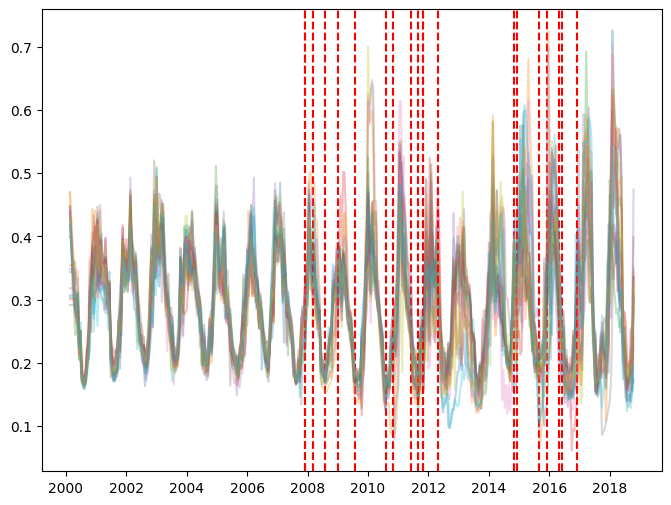

In [12]:
from datetime import datetime

fig, ax = plt.subplots(figsize=(8, 6))

df2 = pd.DataFrame()
df2['fechas'] = fechas

for pixel in testPixel:

    # deforestationDate = datetime(int(df['anio'].iloc[pixel]), int(df['mes'].iloc[pixel]), 1)
    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart:].values

    df2[pixel] = ndvi

    ax.plot(fechas, ndvi, alpha = 0.3)
    ax.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')

### Normalizo NDVI

In [13]:
# === CELL 3: Preprocesamiento y split ===
# Normalización [-1,1]
ndvi = df2.iloc[:,1:].values
minv, maxv = ndvi.min(), ndvi.max()
def normalize(x): return 2*(x - minv)/(maxv - minv) - 1
def denormalize(z): return ((z+1)/2*(maxv - minv)) + minv

# df['ndvi_norm'] = normalize(ndvi)
ndvi_norm = df2.iloc[:,1:].apply(normalize)

In [14]:
# mask = (fechas.year == deforestationDate.year) & (fechas.month == deforestationDate.month)
# deforestationDate = np.where(mask)[0][0]
# train_df = ndvi_norm.iloc[:deforestationDate].reset_index(drop=True)
# test_df = ndvi_norm.iloc[deforestationDate:].reset_index(drop=True)
ndvi_norm

,3921,3533,1562,3957,706,2050,190,913,3172,776,2836,3212,1829,3870,3107,538,2844,1919,3077,3331
0,-0.262238,-0.119747,-0.30833,0.163729,-0.138123,0.017021,0.157102,-0.2288,0.229101,-0.271577,0.066124,0.228498,0.139629,-0.278807,0.160717,-0.151679,0.126676,0.130291,0.101069,0.082091
1,-0.262238,-0.119747,-0.30833,0.020435,-0.138123,0.018226,0.052367,-0.2288,0.079781,-0.271577,-0.037506,0.114701,0.022041,-0.278807,0.02897,-0.151679,0.002159,-0.007833,-0.000452,-0.027966
2,-0.262238,-0.119747,-0.30833,-0.12286,-0.138123,-0.242958,-0.052367,-0.2288,-0.069539,-0.271577,-0.141136,0.000904,-0.095547,-0.278807,-0.102777,-0.151679,-0.122358,-0.145956,-0.101973,-0.138023
3,-0.262238,-0.119747,-0.30833,-0.266155,-0.138123,-0.309233,-0.157102,-0.2288,-0.218858,-0.271577,-0.244766,-0.112894,-0.213135,-0.278807,-0.234523,-0.151679,-0.246875,-0.099864,-0.203495,-0.24808
4,-0.31797,-0.099262,-0.451725,-0.335141,-0.138123,-0.329718,-0.27459,-0.306823,-0.256816,-0.349902,-0.278807,-0.226691,-0.276397,-0.327007,-0.256816,-0.251695,-0.309233,-0.157403,-0.278807,-0.255912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,-0.675855,-0.615906,-0.654466,-0.603254,-0.749962,-0.659587,-0.62163,-0.795451,-0.675252,-0.715319,-0.735502,-0.683989,-0.681579,-0.653261,-0.704172,-0.702967,-0.709294,-0.67706,-0.592408,-0.716222
426,-0.666516,-0.591505,-0.665311,-0.612291,-0.76623,-0.64573,-0.574635,-0.771652,-0.622835,-0.63609,-0.734297,-0.58789,-0.656575,-0.6385,-0.639404,-0.67224,-0.714716,-0.601446,-0.661696,-0.715017
427,-0.630366,-0.574333,-0.646031,-0.522217,-0.711101,-0.553848,-0.57584,-0.676759,-0.610785,-0.605362,-0.766832,-0.42883,-0.625395,-0.571321,-0.421298,-0.609279,-0.687604,-0.630667,-0.597831,-0.798464
428,-0.641211,-0.499322,-0.715921,-0.532158,-0.625546,-0.351107,-0.577045,-0.724055,-0.53487,-0.711101,-0.680374,-0.5662,-0.594216,-0.628559,-0.416177,-0.647537,-0.666215,-0.588492,-0.606869,-0.718632


In [15]:
train_df = ndvi_norm

In [16]:
train_df

,3921,3533,1562,3957,706,2050,190,913,3172,776,2836,3212,1829,3870,3107,538,2844,1919,3077,3331
0,-0.262238,-0.119747,-0.30833,0.163729,-0.138123,0.017021,0.157102,-0.2288,0.229101,-0.271577,0.066124,0.228498,0.139629,-0.278807,0.160717,-0.151679,0.126676,0.130291,0.101069,0.082091
1,-0.262238,-0.119747,-0.30833,0.020435,-0.138123,0.018226,0.052367,-0.2288,0.079781,-0.271577,-0.037506,0.114701,0.022041,-0.278807,0.02897,-0.151679,0.002159,-0.007833,-0.000452,-0.027966
2,-0.262238,-0.119747,-0.30833,-0.12286,-0.138123,-0.242958,-0.052367,-0.2288,-0.069539,-0.271577,-0.141136,0.000904,-0.095547,-0.278807,-0.102777,-0.151679,-0.122358,-0.145956,-0.101973,-0.138023
3,-0.262238,-0.119747,-0.30833,-0.266155,-0.138123,-0.309233,-0.157102,-0.2288,-0.218858,-0.271577,-0.244766,-0.112894,-0.213135,-0.278807,-0.234523,-0.151679,-0.246875,-0.099864,-0.203495,-0.24808
4,-0.31797,-0.099262,-0.451725,-0.335141,-0.138123,-0.329718,-0.27459,-0.306823,-0.256816,-0.349902,-0.278807,-0.226691,-0.276397,-0.327007,-0.256816,-0.251695,-0.309233,-0.157403,-0.278807,-0.255912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,-0.675855,-0.615906,-0.654466,-0.603254,-0.749962,-0.659587,-0.62163,-0.795451,-0.675252,-0.715319,-0.735502,-0.683989,-0.681579,-0.653261,-0.704172,-0.702967,-0.709294,-0.67706,-0.592408,-0.716222
426,-0.666516,-0.591505,-0.665311,-0.612291,-0.76623,-0.64573,-0.574635,-0.771652,-0.622835,-0.63609,-0.734297,-0.58789,-0.656575,-0.6385,-0.639404,-0.67224,-0.714716,-0.601446,-0.661696,-0.715017
427,-0.630366,-0.574333,-0.646031,-0.522217,-0.711101,-0.553848,-0.57584,-0.676759,-0.610785,-0.605362,-0.766832,-0.42883,-0.625395,-0.571321,-0.421298,-0.609279,-0.687604,-0.630667,-0.597831,-0.798464
428,-0.641211,-0.499322,-0.715921,-0.532158,-0.625546,-0.351107,-0.577045,-0.724055,-0.53487,-0.711101,-0.680374,-0.5662,-0.594216,-0.628559,-0.416177,-0.647537,-0.666215,-0.588492,-0.606869,-0.718632


In [19]:
train_df

,3921,3533,1562,3957,706,2050,190,913,3172,776,2836,3212,1829,3870,3107,538,2844,1919,3077,3331
0,-0.262238,-0.119747,-0.30833,0.163729,-0.138123,0.017021,0.157102,-0.2288,0.229101,-0.271577,0.066124,0.228498,0.139629,-0.278807,0.160717,-0.151679,0.126676,0.130291,0.101069,0.082091
1,-0.262238,-0.119747,-0.30833,0.020435,-0.138123,0.018226,0.052367,-0.2288,0.079781,-0.271577,-0.037506,0.114701,0.022041,-0.278807,0.02897,-0.151679,0.002159,-0.007833,-0.000452,-0.027966
2,-0.262238,-0.119747,-0.30833,-0.12286,-0.138123,-0.242958,-0.052367,-0.2288,-0.069539,-0.271577,-0.141136,0.000904,-0.095547,-0.278807,-0.102777,-0.151679,-0.122358,-0.145956,-0.101973,-0.138023
3,-0.262238,-0.119747,-0.30833,-0.266155,-0.138123,-0.309233,-0.157102,-0.2288,-0.218858,-0.271577,-0.244766,-0.112894,-0.213135,-0.278807,-0.234523,-0.151679,-0.246875,-0.099864,-0.203495,-0.24808
4,-0.31797,-0.099262,-0.451725,-0.335141,-0.138123,-0.329718,-0.27459,-0.306823,-0.256816,-0.349902,-0.278807,-0.226691,-0.276397,-0.327007,-0.256816,-0.251695,-0.309233,-0.157403,-0.278807,-0.255912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,-0.675855,-0.615906,-0.654466,-0.603254,-0.749962,-0.659587,-0.62163,-0.795451,-0.675252,-0.715319,-0.735502,-0.683989,-0.681579,-0.653261,-0.704172,-0.702967,-0.709294,-0.67706,-0.592408,-0.716222
426,-0.666516,-0.591505,-0.665311,-0.612291,-0.76623,-0.64573,-0.574635,-0.771652,-0.622835,-0.63609,-0.734297,-0.58789,-0.656575,-0.6385,-0.639404,-0.67224,-0.714716,-0.601446,-0.661696,-0.715017
427,-0.630366,-0.574333,-0.646031,-0.522217,-0.711101,-0.553848,-0.57584,-0.676759,-0.610785,-0.605362,-0.766832,-0.42883,-0.625395,-0.571321,-0.421298,-0.609279,-0.687604,-0.630667,-0.597831,-0.798464
428,-0.641211,-0.499322,-0.715921,-0.532158,-0.625546,-0.351107,-0.577045,-0.724055,-0.53487,-0.711101,-0.680374,-0.5662,-0.594216,-0.628559,-0.416177,-0.647537,-0.666215,-0.588492,-0.606869,-0.718632


#### Definicion listas de train y test

In [17]:
train_list = []
test_list = []
nTrain = 15
for i in range(nTrain):
    train_list.append(train_df[i].values)

nTest = 5
for i in range(nTest):
    test_list.append(train_df[i+nTrain].values)

KeyError: 0

### Definicion Entorno gym.Env para que tome stable_baselines3

In [ ]:
# === CELL 4: Definir entorno NDVIEnv ===

''' 
class NDVIEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, series, window=23):
        super().__init__()
        self.actionMin, self.actionMax = -1.5, 1.5
        self.series = np.array(series, dtype=np.float16)
        self.window = window
        self.action_space = spaces.Box(low=self.actionMin, high=self.actionMax, shape=(1,), dtype=np.float16)
        self.observation_space = spaces.Box(low=self.actionMin, high=self.actionMax, shape=(self.window,), dtype=np.float16)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.idx = self.window
        self.done = False
        obs = self.series[self.idx-self.window:self.idx].copy()
        return obs, {}

    def step(self, action):
        pred = float(np.clip(action[0], self.actionMin, self.actionMax))
        true_val = float(self.series[self.idx])
        reward = - (true_val - pred)**2  # negative MSE
        self.idx += 1
        self.done = self.idx >= len(self.series)
        obs = self.series[self.idx-self.window:self.idx].copy() if not self.done else np.zeros(self.window, dtype=np.float16)
        return obs, reward, self.done, False, {}

    def render(self):
        pass

# Prueba del entorno
env = NDVIEnv(train_df.values, window=23)
obs, _ = env.reset()
print("Observación inicial shape:", obs.shape)
'''

In [ ]:
# class NDVIMultiEnv_back(gym.Env):
#     """
#     Entorno NDVI multivariado.
#     Cada observación es un vector con NDVI de n_series en una ventana temporal.
#     """
#     metadata = {"render.modes": ["human"]}

#     def __init__(self, series_list, window=23):
#         super().__init__()

#         # series_list: lista de arrays 1D (una por ubicación o variable)
#         self.series_list = series_list
#         self.n_series = len(series_list)
#         self.window = window
#         self.length = min(len(s) for s in series_list)

#         # Normalizamos y apilamos
#         self.data = np.stack([s[:self.length] for s in series_list], axis=1)

#         # Espacios de observación y acción
#         self.observation_space = spaces.Box(
#             low=-1.5, high=1.5, shape=(self.window, self.n_series), dtype=np.float32
#         )
#         self.action_space = spaces.Box(low=-1.5, high=1.5, shape=(self.n_series,), dtype=np.float32)

#         self.current_step = self.window

#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)
#         self.current_step = self.window
#         obs = self.data[self.current_step - self.window : self.current_step]
#         return obs, {}

#     def step(self, action):
#         target = self.data[self.current_step]
#         reward = -np.mean((action - target) ** 2)  # recompensa: minimizar error cuadrático medio

#         self.current_step += 1
#         done = self.current_step >= self.length
#         next_obs = (
#             self.data[self.current_step - self.window : self.current_step]
#             if not done
#             else np.zeros_like(self.observation_space.sample())
#         )

#         info = {}
#         return next_obs, reward, done, False, info
    
class NDVIMultiEnv(gym.Env):
    def __init__(self, series_list, window=23):
        super().__init__()
        
        # Convertir explícitamente a float32
        self.series_list = [np.array(s, dtype=np.float32) for s in series_list]
        self.n_series = len(series_list)
        self.window = window
        self.length = min(len(s) for s in series_list)

        # Asegurarse que data sea float32
        self.data = np.stack([s[:self.length] for s in self.series_list], axis=1).astype(np.float32)

        self.observation_space = spaces.Box(
            low=-1.5, high=1.5, 
            shape=(self.window, self.n_series), 
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1.5, high=1.5, 
            shape=(self.n_series,), 
            dtype=np.float32
        )

        self.current_step = self.window

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window
        obs = self.data[self.current_step - self.window : self.current_step].astype(np.float32)
        return obs, {}

    def step(self, action):
        # Obtener el valor objetivo actual
        target = self.data[self.current_step]
        
        # Calcular recompensa como el error cuadrático medio negativo
        reward = -np.mean((action - target) ** 2)
        
        # Avanzar un paso
        self.current_step += 1
        
        # Verificar si el episodio ha terminado
        done = self.current_step >= self.length
        
        # Obtener la siguiente observación
        if not done:
            next_obs = self.data[self.current_step - self.window : self.current_step].astype(np.float32)
        else:
            next_obs = np.zeros_like(self.observation_space.sample(), dtype=np.float32)
        
        info = {}
        return next_obs, reward, done, False, info

In [ ]:
class NDVIMultiEnv_vec(gym.Env):
    def __init__(self, series_data, window=23):
        """
        Args:
            series_data: numpy array of shape (2, length_series, num_series)
                        First index: 0=NDVI, 1=binary class
                        Second index: temporal length
                        Third index: number of different series
        """
        super().__init__()
        
        # Convertir y validar entrada
        self.series_data = np.array(series_data, dtype=np.float32)
        assert len(self.series_data.shape) == 3, "Input must be 3D array"
        assert self.series_data.shape[0] == 2, "First dimension must be 2 (NDVI and class)"
        
        self.n_features = 2
        self.n_series = self.series_data.shape[2]
        self.length = self.series_data.shape[1]
        self.window = window
        
        # Current episode tracking
        self.current_series = 0
        self.current_step = self.window

        # Espacios de observación y acción
        self.observation_space = spaces.Dict({
            'continuous': spaces.Box(
                low=-1.5, high=1.5,
                shape=(self.window,),
                dtype=np.float32
            ),
            'categorical': spaces.Box(
                low=0, high=1,
                shape=(self.window,),
                dtype=np.float32
            )
        })

        self.action_space = spaces.Dict({
            'continuous': spaces.Box(
                low=-1.5, high=1.5,
                shape=(1,),
                dtype=np.float32
            ),
            'categorical': spaces.Discrete(2)
        })

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        # Reset steps and randomly select a new series
        self.current_step = self.window
        self.current_series = self.np_random.integers(0, self.n_series)
        
        # Get initial window of observations
        obs = {
            'continuous': self.series_data[0, self.current_step-self.window:self.current_step, self.current_series],
            'categorical': self.series_data[1, self.current_step-self.window:self.current_step, self.current_series]
        }
        
        return obs, {}

    def step(self, action):
        # Get current targets
        target_continuous = self.series_data[0, self.current_step, self.current_series]
        target_categorical = self.series_data[1, self.current_step, self.current_series]
        
        # Calculate rewards
        reward_continuous = -(action['continuous'][0] - target_continuous) ** 2
        reward_categorical = float(action['categorical'] == int(target_categorical))
        reward = 0.7 * reward_continuous + 0.3 * reward_categorical
        
        # Advance step
        self.current_step += 1
        
        # Check if episode is done
        done = self.current_step >= self.length
        
        # Get next observation
        if not done:
            next_obs = {
                'continuous': self.series_data[0, self.current_step-self.window:self.current_step, self.current_series],
                'categorical': self.series_data[1, self.current_step-self.window:self.current_step, self.current_series]
            }
        else:
            next_obs = {
                'continuous': np.zeros(self.window, dtype=np.float32),
                'categorical': np.zeros(self.window, dtype=np.float32)
            }
        
        return next_obs, reward, done, False, {}

### Sintetizo serie booleana

In [ ]:
''' # Ejemplo: tres series de NDVI simuladas
t = np.linspace(0, 4*np.pi, 200)
serie1 = np.sin(t)
serie2 = np.sin(t + 0.5)
serie3 = np.sin(t - 0.7)
series_list = [serie1, serie2, serie3] '''

input2 = fechas < deforestationDate
input2 = [np.float64(1.0) if x == True else 0 for x in input2]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fechas, ndvi, alpha = 0.3)
ax.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax.plot(fechas, input2)

### Pego las dos series

In [ ]:
series_list = [train_list[0], input2]

In [ ]:
series_list

## Entrenamiento

In [ ]:
# Crear entorno
env = NDVIMultiEnv(series_list, window=23)

obs, _ = env.reset()
print("Shape de observación:", obs.shape)

In [ ]:
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)

## Evaluacion

### evaluacion con Train (si no anda estamos en el horno)

In [ ]:
obs, _ = env.reset()
preds = []
rewards = []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    preds.append(action)
    rewards.append(reward)

preds = np.array(preds)
true_vals = env.data[env.window:env.window + len(preds)]

# Graficar cada variable
import matplotlib.pyplot as plt

for i in range(env.n_series):
    plt.figure(figsize=(10,4))
    plt.plot(true_vals[:, i], label=f"Real NDVI {i}")
    plt.plot(preds[:, i], '--', label=f"Predicho {i}")
    plt.legend()
    plt.title(f"Comparación NDVI {i}")
    plt.tight_layout()
    plt.show()


### Evaluacion con Test

In [ ]:
for k in test_list:
    # Create test environment with one of the test series plus the boolean input
    test_input = [k, input2]  # Using first test series and same boolean input
    test_env = NDVIMultiEnv(test_input, window=23)

    # Reset environment and prepare for evaluation
    obs, _ = test_env.reset()
    preds = []
    rewards = []

    # Run predictions
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)

    # Convert predictions to numpy array
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]

    # Plot results for each variable
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot NDVI series
    ax1.plot(true_vals[:, 0], label="Real NDVI", color='blue')
    ax1.plot(preds[:, 0], '--', label="Predicted NDVI", color='red')
    ax1.set_title("NDVI Comparison")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")

    # Plot boolean input series
    ax2.plot(true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(preds[:, 1], '--', label="Predicted Class", color='orange')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Timestep")
    plt.tight_layout()
    plt.show()

### Evaluaciones raras confundiendo

#### Es particular, le digo que sigue en estado bosque a ver que hace

In [ ]:
input3 = np.ones(len(input2), dtype=np.float32)

In [ ]:
input3.shape

In [ ]:
preds.shape

In [ ]:
# Create test environment with one of the test series plus the boolean input
test_input = [test_list[0], input3]  # Using first test series and altered boolean input
test_env = NDVIMultiEnv(test_input, window=23)

# Reset environment and prepare for evaluation
obs, _ = test_env.reset()
preds = []
rewards = []

# Run predictions
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)
    preds.append(action)
    rewards.append(reward)

# Convert predictions to numpy array
preds = np.array(preds)
true_vals = test_env.data[test_env.window:test_env.window + len(preds)]

# Plot results for each variable
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot NDVI series
ax1.plot(fechas[23:], true_vals[:, 0], label="Real NDVI", color='green')
ax1.plot(fechas[23:], preds[:, 0], '--', label="Predicted NDVI", color='blue')
ax1.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax1.set_title("NDVI Comparison")
ax1.legend()
ax1.set_ylabel("Normalized NDVI")

# Plot boolean input series
ax2.plot(fechas[23:], true_vals[:, 1], label="Real Class", color='green')
ax2.plot(fechas[23:], preds[:, 1], '--', label="Predicted Class", color='orange')
ax2.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax2.set_title("Class Prediction")
ax2.legend()
ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
ax2.set_xlabel("Timestep")
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
input4 = np.zeros(len(input2), dtype=np.float32)

In [ ]:
# Create test environment with one of the test series plus the boolean input
test_input = [test_list[0], input4]  # Using first test series and same boolean input
test_env = NDVIMultiEnv(test_input, window=23)

# Reset environment and prepare for evaluation
obs, _ = test_env.reset()
preds = []
rewards = []

# Run predictions
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)
    preds.append(action)
    rewards.append(reward)

# Convert predictions to numpy array
preds = np.array(preds)
true_vals = test_env.data[test_env.window:test_env.window + len(preds)]

# Plot results for each variable
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot NDVI series
ax1.plot(fechas[23:], true_vals[:, 0], label="Real NDVI", color='blue')
ax1.plot(fechas[23:], preds[:, 0], '--', label="Predicted NDVI", color='red')
ax1.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax1.set_title("NDVI Comparison")
ax1.legend()
ax1.set_ylabel("Normalized NDVI")

# Plot boolean input series
ax2.plot(fechas[23:], true_vals[:, 1], label="Real Class", color='green')
ax2.plot(fechas[23:], preds[:, 1], '--', label="Predicted Class", color='orange')
ax2.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax2.set_title("Class Prediction")
ax2.legend()
ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
ax2.set_xlabel("Timestep")
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()